# XGBoost Fraud Detection Model

This notebook trains an XGBoost classifier using both original dataset variables and engineered fraud indicators.

The objective is to improve fraud recall while maintaining reasonable precision on a highly imbalanced fraud detection dataset.

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/DataSet.csv")

In [3]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

## Feature Engineering

Several fraud indicators and interaction features were created based on patterns discovered during exploratory analysis.

These engineered features expose high-risk regions of the feature space that may not be fully captured by the original variables alone.

In [4]:
df["F115_high"] = (df["F115"] > 0.78).astype(int)

df["F2582_hot"] = (
    (df["F2582"] > -0.03)
    & (df["F2582"] <= 0)
).astype(int)

df["F2956_hot"] = (
    (df["F2956"] > 19)
    & (df["F2956"] <= 32)
).astype(int)

df["F531_hot"] = (
    (df["F531"] > 0.95)
    & (df["F531"] <= 1.35)
).astype(int)

df["F2737_safe"] = (
    (df["F2737"] > 0)
    & (df["F2737"] <= 0.04)
).astype(int)

df["F2582_F531"] = (
    df["F2582_hot"]
    & df["F531_hot"]
).astype(int)

df["fraud_cluster_1"] = (
    df["F2582_hot"]
    & df["F2956_hot"]
    & df["F531_hot"]
).astype(int)

df["f3836_hot"] = (
    (df["F3836"] > 148.596 ) &
    (df["F3836"] <= 20077.212)
).astype(int)

df["F2956_F115"] = (
    df["F2956_hot"] &
    df["F115_high"]
).astype(int)

df["F2582_pos_F2956_low"] = (
    (df["F2582"] > 0.15) &
    (df["F2956"] < 60)
).astype(int)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23140\3734788897.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["F115_high"] = (df["F115"] > 0.78).astype(int)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23140\3734788897.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["F2582_hot"] = (
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23140\3734788897.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all 

## Feature Selection

The final feature set consists of original dataset variables, engineered fraud indicators, interaction features, and missing-value indicators derived during exploratory analysis.

These features were selected based on fraud-rate analysis, feature importance investigation, and model performance.

In [5]:
features = [
    "F115",
    "F2582",
    "F2956",
    "F531",
    "F2737",
    "F670",
    "F673",
    "F3891",
    "F3889",

    # engineered features

    "F115_high",
    "F2582_hot",
    "F2956_hot",
    "F531_hot",
    "F2737_safe",
    "F2582_F531",
    "fraud_cluster_1",
    "f3836_hot",
    "F2956_F115",
    "F2582_pos_F2956_low"

]

family_cols = [
    "F664","F665","F666",
    "F667","F668","F669",
    "F670","F671","F672",
    "F673","F674","F675",

    "F1","F2","F3","F4","F5","F6","F7","F8","F9","F10","F12"
]

for col in family_cols:
    df[f"{col}_missing"] = df[col].isna().astype(int)

features += [f"{col}_missing" for col in family_cols]

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23140\437142712.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_missing"] = df[col].isna().astype(int)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23140\437142712.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_missing"] = df[col].isna().astype(int)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23140\437142712.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfo

In [6]:
X = pd.get_dummies(
    df[features],
    columns=["F3891", "F3889"],
    dummy_na=True
)

y = df["F3924"]

## Data Preparation

Categorical variables are one-hot encoded and missing values are handled prior to model training.

A stratified train-test split is used to preserve fraud prevalence across datasets.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train = X_train.fillna(-999)
X_test = X_test.fillna(-999)

## Model Training

XGBoost is trained using class weighting to address severe class imbalance.

The model is optimized for fraud detection performance rather than overall accuracy.

In [8]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=110,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Model Evaluation

Performance is evaluated across multiple probability thresholds.

Because fraudulent accounts represent a small minority of observations, recall is prioritized over accuracy.

In [9]:
y_prob = xgb.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.3, 0.2, 0.1]:

    y_pred = (y_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")

    print(confusion_matrix(y_test, y_pred))

    print(classification_report(y_test, y_pred))


Threshold: 0.5
[[1745   56]
 [   9    7]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1801
           1       0.11      0.44      0.18        16

    accuracy                           0.96      1817
   macro avg       0.55      0.70      0.58      1817
weighted avg       0.99      0.96      0.97      1817


Threshold: 0.3
[[1688  113]
 [   8    8]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1801
           1       0.07      0.50      0.12        16

    accuracy                           0.93      1817
   macro avg       0.53      0.72      0.54      1817
weighted avg       0.99      0.93      0.96      1817


Threshold: 0.2
[[1626  175]
 [   4   12]]
              precision    recall  f1-score   support

           0       1.00      0.90      0.95      1801
           1       0.06      0.75      0.12        16

    accuracy                           0.90      1817

In [10]:
for threshold in [0.25, 0.30, 0.35, 0.40, 0.45]:
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0

    print(
        f"Threshold={threshold:.2f} | "
        f"TP={tp} FP={fp} FN={fn} | "
        f"Precision={precision:.3f} Recall={recall:.3f}"
    )

Threshold=0.25 | TP=9 FP=143 FN=7 | Precision=0.059 Recall=0.562
Threshold=0.30 | TP=8 FP=113 FN=8 | Precision=0.066 Recall=0.500
Threshold=0.35 | TP=8 FP=98 FN=8 | Precision=0.075 Recall=0.500
Threshold=0.40 | TP=8 FP=83 FN=8 | Precision=0.088 Recall=0.500
Threshold=0.45 | TP=7 FP=74 FN=9 | Precision=0.086 Recall=0.438


## Feature Importance Analysis

Feature importance scores provide insight into which variables contribute most strongly to fraud predictions.

In [11]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(15)

F2956_hot             0.089096
F1_missing            0.072393
F9_missing            0.069688
F2_missing            0.069146
F2582_F531            0.068366
F2582                 0.051964
F3891_student         0.040670
F3889_G365D           0.039905
F3891_selfemployed    0.039804
F7_missing            0.039202
F2956                 0.035969
F8_missing            0.034744
F3889_L180D           0.033133
F673                  0.033015
F2737                 0.031261
dtype: float32

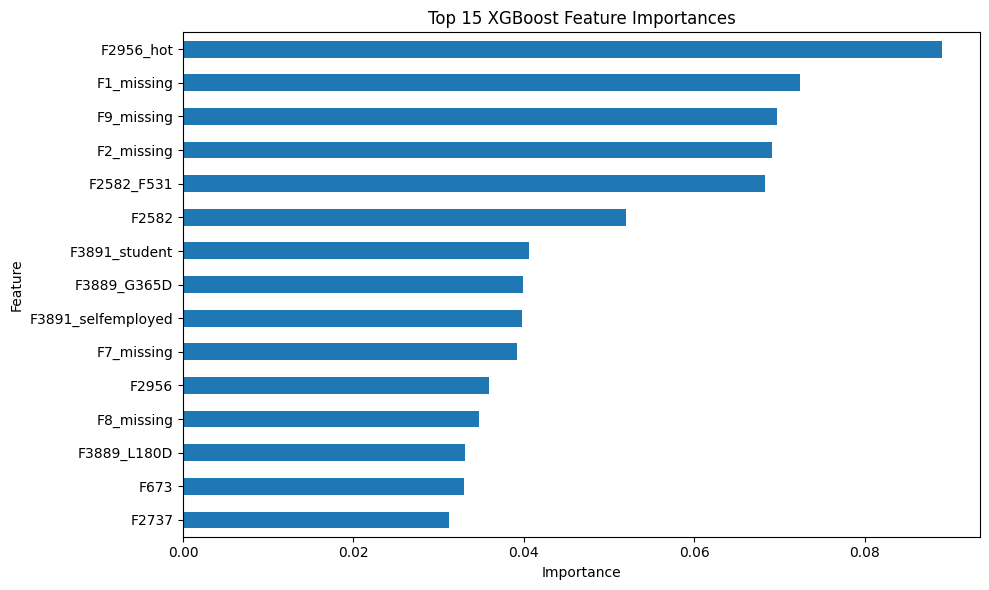

<Figure size 640x480 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

importance.head(15).sort_values().plot.barh()

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

plt.savefig("../figures/xgb_feature_importance.png",
            bbox_inches="tight")

## Ranking Performance

Average Precision evaluates the model's ability to rank fraudulent accounts ahead of legitimate accounts independent of a fixed threshold.

In [13]:
from sklearn.metrics import average_precision_score

ap = average_precision_score(y_test, y_prob)

print("Average Precision:", ap)

Average Precision: 0.36134835491527334


## Exporting Predictions

Predicted probabilities are saved for later comparison with other models and ensemble construction.

In [14]:
xgb_probs = pd.DataFrame({
    "prob": y_prob
}, index=X_test.index)

xgb_probs.to_csv("../data/processed/xgb_probs.csv")

In [15]:
pd.DataFrame({
    "actual": y_test
}).to_csv("../data/processed/y_test.csv")

## Key Findings

The XGBoost model significantly improved fraud detection performance compared to the CatBoost baseline.

Key observations:

- Engineered fraud indicators contributed substantially to model performance.
- Missing-value indicators proved highly informative.
- The model achieved strong fraud recall across multiple thresholds.
- Feature importance analysis consistently highlighted F2737, F531, F2956, F2582, and F115 as important predictors.

The predicted probabilities generated in this notebook are later used for ensemble construction and comparison with LightGBM and Neural Network models.